In [27]:
import sys
import time
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle, Circle as MplCircle
import scipy.ndimage as ndi
from scipy.ndimage import rotate as ndi_rotate

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.data.analysis import Circle
from src.data.detector import DetectorData

## Configuration

In [28]:
# ==================== ALL CONFIGURATION ====================
# Data paths
DATA_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25")
INPUT_FILE = DATA_PATH / 'mbo_aic144_single_foil_processed.pkl'
OUTPUT_FILE = DATA_PATH / 'mbo_aic144_single_foil_rotated.npz'

# Image parameters
PIXEL_SIZE_MM = 0.074           # Pixel size in mm
LOW_THRESHOLD_VALUE = 50        # Pixel value below which pixels are white in colormap
MARGIN_MM = 4.0                 # Margin around circle for cropping [mm]

# Iso-signal contour levels
ISO_LEVELS = [1300, 1400, 1500, 1600]
ISO_COLORS = ['cyan', 'magenta', 'yellow', 'orange']

# Zoom region for detailed view
ZOOM_XLIM = (46, 52)            # mm
ZOOM_YLIM = (50, 25)            # mm (inverted for image coords)

# Gravity centers / rotation optimization
ROT_THRESHOLD = 1400            # Threshold for gravity center calculation
ROT_Y_MIN_MM, ROT_Y_MAX_MM = 25, 50  # Y range for slices
ROT_SLICE_MM = 1.0              # Slice width for gravity centers
ROT_ANGLE_MIN, ROT_ANGLE_MAX = -5.0, 5.0  # Search range [degrees]
ROT_N_STEPS = 100               # Brute-force grid points

# Optimization method: 'bisection' or 'bruteforce'
OPT_METHOD = 'bisection'
BISECT_TOL = 0.01               # Bisection convergence tolerance [degrees]

# Profile extraction
PROFILE_STRIPE_MM = 5.0         # Central stripe thickness for horizontal profile

## Helper Functions

In [29]:
def create_cmap():
    """Colormap: white→green→red with NaN as white."""
    cmap = LinearSegmentedColormap.from_list('wgr', ['white', 'green', 'red'])
    cmap.set_bad('white')
    return cmap

def smooth_image(img):
    """Apply median + gaussian smoothing."""
    return ndi.gaussian_filter(ndi.median_filter(img, size=7), sigma=3)

def rotate_around_center(image, angle_deg, center_px):
    """Rotate image around specified center, pad with zeros."""
    h, w = image.shape
    cx, cy = center_px
    shifted = ndi.shift(image, [h/2 - cy, w/2 - cx], mode='constant', cval=0)
    rotated = ndi_rotate(shifted, angle_deg, reshape=False, mode='constant', cval=0)
    return ndi.shift(rotated, [cy - h/2, cx - w/2], mode='constant', cval=0)

def calc_gravity_centers(img, threshold, y_min_mm, y_max_mm, slice_mm, px_mm):
    """Calculate gravity centers for Y slices above threshold."""
    n_slices = int((y_max_mm - y_min_mm) / slice_mm)
    centers = []
    for i in range(n_slices):
        y0_px = int((y_min_mm + i * slice_mm) / px_mm)
        y1_px = int((y_min_mm + (i + 1) * slice_mm) / px_mm)
        slc = img[y0_px:y1_px, :]
        mask = slc > threshold
        if mask.any():
            y_idx, x_idx = np.where(mask)
            vals = slc[mask]
            x_ctr = (x_idx * vals).sum() / vals.sum() * px_mm
            y_ctr = (y0_px + (y_idx * vals).sum() / vals.sum()) * px_mm
            centers.append((x_ctr, y_ctr))
    return np.array(centers) if centers else np.array([]).reshape(0, 2)

def calc_angle_from_vertical(centers):
    """Calculate angle from vertical for fitted line through centers."""
    if len(centers) < 2:
        return np.inf, (0, 0)
    fit_a, fit_b = np.polyfit(centers[:, 1], centers[:, 0], 1)
    return np.degrees(np.arctan(fit_a)), (fit_a, fit_b)

def eval_rotation(angle, image, center_px, threshold, y_min, y_max, slice_mm, px_mm):
    """Evaluate angle from vertical for given rotation."""
    img_rot = rotate_around_center(image, angle, center_px)
    img_sm = smooth_image(img_rot)
    centers = calc_gravity_centers(img_sm, threshold, y_min, y_max, slice_mm, px_mm)
    return calc_angle_from_vertical(centers)[0]

def plot_dual_view(img, centers, fit_coeffs, circle_mm, extent, xlim_crop, ylim_crop, 
                   zoom_xlim, zoom_ylim, levels, title_left, title_right):
    """Plot cropped and zoomed views with iso-signals and gravity centers."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    cx_mm, cy_mm, r_mm = circle_mm
    h, w = img.shape
    x_mm, y_mm = np.arange(w) * PIXEL_SIZE_MM, np.arange(h) * PIXEL_SIZE_MM
    
    y_fit = np.array([ROT_Y_MIN_MM, ROT_Y_MAX_MM])
    x_fit = fit_coeffs[0] * y_fit + fit_coeffs[1]
    
    for i, (ax, xlim, ylim, aspect, title) in enumerate([
        (axes[0], xlim_crop, ylim_crop, 'equal', title_left),
        (axes[1], zoom_xlim, zoom_ylim, 'auto', title_right)
    ]):
        im = ax.imshow(img, cmap=create_cmap(), extent=extent, aspect=aspect)
        cs = ax.contour(x_mm, y_mm, img, levels=levels, colors=ISO_COLORS, linewidths=1.5)
        ax.clabel(cs, inline=True, fontsize=8)
        if len(centers) > 0:
            ax.scatter(centers[:, 0], centers[:, 1], c='black', s=30, zorder=5)
            ax.plot(x_fit, y_fit, 'k--', lw=2, label=f'X = {fit_coeffs[0]:.4f}*Y + {fit_coeffs[1]:.1f}')
            ax.legend(loc='upper right', fontsize=8)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set(xlabel='x [mm]', ylabel='y [mm]', title=title)
        ax.grid(True, lw=0.5, c='k', alpha=0.3)
        plt.colorbar(im, ax=ax, shrink=0.8, label='Value')
        
        if i == 0:  # Add circle and zoom rectangle on left plot
            ax.add_patch(MplCircle((cx_mm, cy_mm), r_mm, color='blue', fill=False, lw=2))
            ax.add_patch(Rectangle((zoom_xlim[0], zoom_ylim[1]), 
                                   zoom_xlim[1]-zoom_xlim[0], zoom_ylim[0]-zoom_ylim[1], 
                                   ec='black', fc='none', lw=2))
    plt.tight_layout()
    plt.show()

## Load Data & Initial 180° Rotation

In [30]:
# Load processed foil data
with open(INPUT_FILE, 'rb') as f:
    foil_data: DetectorData = pickle.load(f)

# Rotate image 180 degrees
image_rotated = np.rot90(foil_data.raw.image, k=2)
h, w = foil_data.raw.image.shape

# Update circle center after rotation: (x,y) -> (w-x, h-y)
circle_rotated = Circle(
    x=w - foil_data.circle.x,
    y=h - foil_data.circle.y,
    r=foil_data.circle.r
)

# Convert to mm
cx_mm = circle_rotated.x * PIXEL_SIZE_MM
cy_mm = circle_rotated.y * PIXEL_SIZE_MM
r_mm = circle_rotated.r * PIXEL_SIZE_MM
circle_mm = (cx_mm, cy_mm, r_mm)
center_px = (circle_rotated.x, circle_rotated.y)

# Extent and crop limits
extent = [0, w * PIXEL_SIZE_MM, h * PIXEL_SIZE_MM, 0]
xlim_crop = (cx_mm - r_mm - MARGIN_MM, cx_mm + r_mm + MARGIN_MM)
ylim_crop = (cy_mm + r_mm + MARGIN_MM, cy_mm - r_mm - MARGIN_MM)

print(f"Loaded: {INPUT_FILE.name}")
print(f"Image: {h}×{w} px = {h*PIXEL_SIZE_MM:.1f}×{w*PIXEL_SIZE_MM:.1f} mm")
print(f"Circle: center=({cx_mm:.2f}, {cy_mm:.2f}) mm, r={r_mm:.2f} mm")

Loaded: mbo_aic144_single_foil_processed.pkl
Image: 1024×1024 px = 75.8×75.8 mm
Circle: center=(36.39, 38.81) mm, r=17.88 mm


## Smoothing & Initial Analysis

Gravity centers: 24 slices
Fitted line: X = 0.0433*Y + 47.64
Angle from vertical: 2.48°


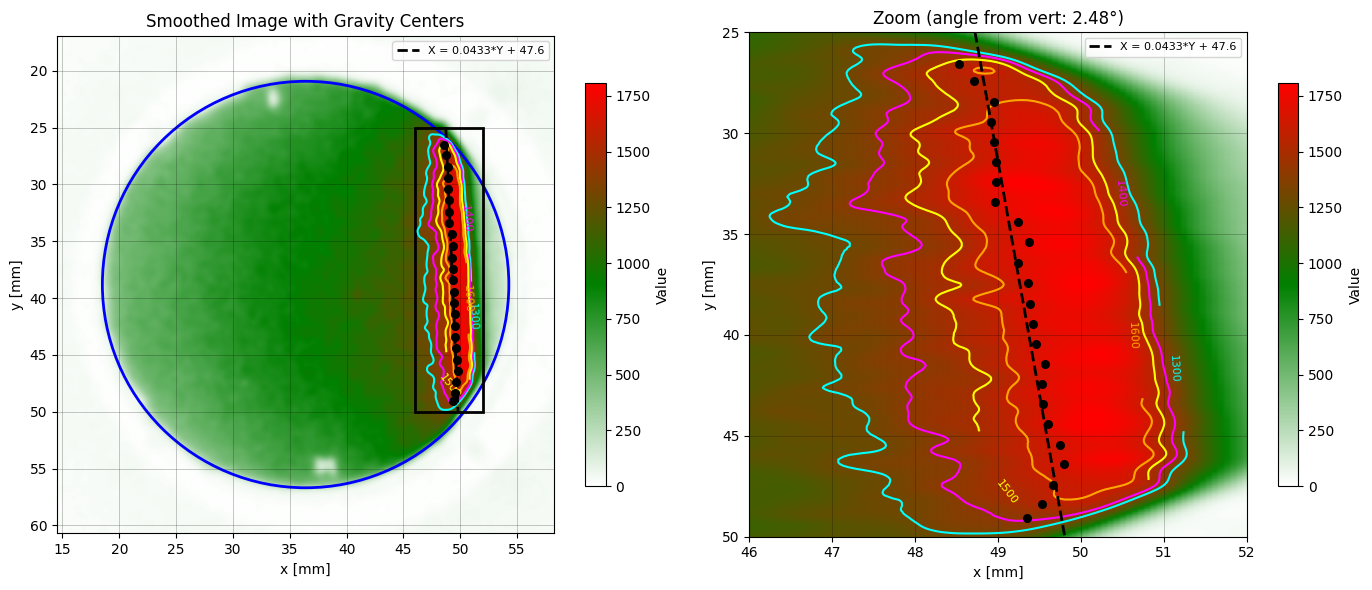

In [31]:
# Smooth image and calculate gravity centers
img_smooth = smooth_image(image_rotated)
gravity_centers = calc_gravity_centers(img_smooth, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
angle_vert, fit_coeffs = calc_angle_from_vertical(gravity_centers)

print(f"Gravity centers: {len(gravity_centers)} slices")
print(f"Fitted line: X = {fit_coeffs[0]:.4f}*Y + {fit_coeffs[1]:.2f}")
print(f"Angle from vertical: {angle_vert:.2f}°")

# Visualize
plot_dual_view(img_smooth, gravity_centers, fit_coeffs, circle_mm, extent, xlim_crop, ylim_crop,
               ZOOM_XLIM, ZOOM_YLIM, ISO_LEVELS,
               'Smoothed Image with Gravity Centers',
               f'Zoom (angle from vert: {angle_vert:.2f}°)')

## Rotation Optimization

Find optimal rotation angle to minimize tilt (angle from vertical ≈ 0)

In [32]:
# Run selected optimization method
t0 = time.time()

if OPT_METHOD == 'bruteforce':
    print(f"Brute-force: {ROT_N_STEPS} points from {ROT_ANGLE_MIN}° to {ROT_ANGLE_MAX}°")
    angles = np.linspace(ROT_ANGLE_MIN, ROT_ANGLE_MAX, ROT_N_STEPS)
    costs = []
    for i, ang in enumerate(angles):
        cost = abs(eval_rotation(ang, image_rotated, center_px, ROT_THRESHOLD, 
                                 ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM))
        costs.append(cost)
        if (i + 1) % 20 == 0:
            print(f"  [{i+1:3d}/{ROT_N_STEPS}] angle={ang:+.2f}°, |vert|={cost:.4f}°")
    costs = np.array(costs)
    best_idx = np.argmin(costs)
    best_angle, opt_cost = angles[best_idx], costs[best_idx]
    opt_data = (angles, costs, best_idx)
    
else:  # bisection
    print(f"Bisection: tolerance={BISECT_TOL}°")
    a, b = ROT_ANGLE_MIN, ROT_ANGLE_MAX
    fa = eval_rotation(a, image_rotated, center_px, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
    fb = eval_rotation(b, image_rotated, center_px, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
    history = [(a, fa), (b, fb)]
    iteration = 0
    
    while (b - a) > BISECT_TOL:
        iteration += 1
        mid = (a + b) / 2
        fmid = eval_rotation(mid, image_rotated, center_px, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
        history.append((mid, fmid))
        if fa * fmid < 0:
            b, fb = mid, fmid
        else:
            a, fa = mid, fmid
        print(f"  [{iteration:2d}] mid={mid:+.4f}°, f(mid)={fmid:+.6f}°")
    
    best_angle = (a + b) / 2
    opt_cost = abs(eval_rotation(best_angle, image_rotated, center_px, ROT_THRESHOLD, 
                                 ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM))
    opt_data = np.array(history)

opt_time = time.time() - t0
print(f"\n{OPT_METHOD.title()}: {opt_time:.1f}s, optimal={best_angle:.4f}°, |vert|={opt_cost:.4f}°")

Bisection: tolerance=0.01°
  [ 1] mid=+0.0000°, f(mid)=+2.489888°
  [ 2] mid=-2.5000°, f(mid)=+0.320398°
  [ 3] mid=-3.7500°, f(mid)=-0.756370°
  [ 4] mid=-3.1250°, f(mid)=-0.235851°
  [ 5] mid=-2.8125°, f(mid)=+0.061720°
  [ 6] mid=-2.9688°, f(mid)=-0.084016°
  [ 7] mid=-2.8906°, f(mid)=-0.021297°
  [ 8] mid=-2.8516°, f(mid)=+0.025376°
  [ 9] mid=-2.8711°, f(mid)=+0.010938°
  [10] mid=-2.8809°, f(mid)=+0.001458°

Bisection: 10.2s, optimal=-2.8857°, |vert|=0.0095°


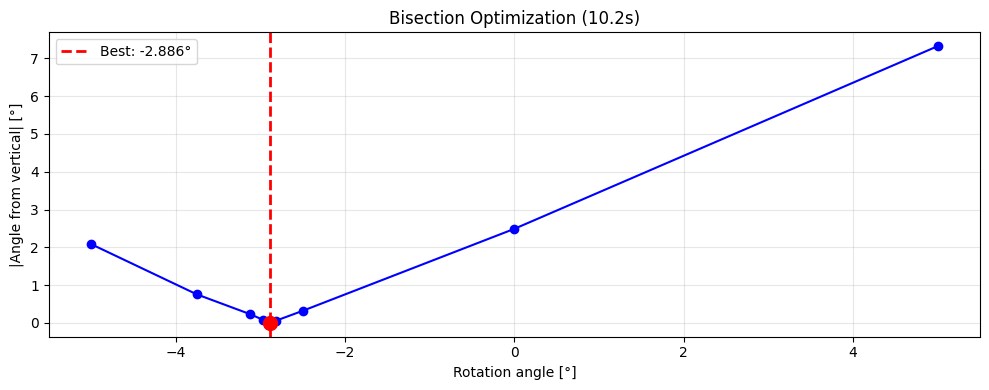

In [33]:
# Plot cost function
fig, ax = plt.subplots(figsize=(10, 4))
if OPT_METHOD == 'bruteforce':
    angles, costs, best_idx = opt_data
    ax.plot(angles, costs, 'b-', lw=1.5)
else:
    sorted_idx = np.argsort(opt_data[:, 0])
    ax.plot(opt_data[sorted_idx, 0], np.abs(opt_data[sorted_idx, 1]), 'bo-', lw=1.5, ms=6)
ax.axvline(best_angle, c='r', ls='--', lw=2, label=f'Best: {best_angle:.3f}°')
ax.scatter([best_angle], [opt_cost], c='r', s=100, zorder=5)
ax.set(xlabel='Rotation angle [°]', ylabel='|Angle from vertical| [°]',
       title=f'{OPT_METHOD.title()} Optimization ({opt_time:.1f}s)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [34]:
## Apply Optimal Rotation & Save Results

After rotation by -2.886°:
  Line: X = -0.000166*Y + 49.32
  Angle from vertical: -0.0095°


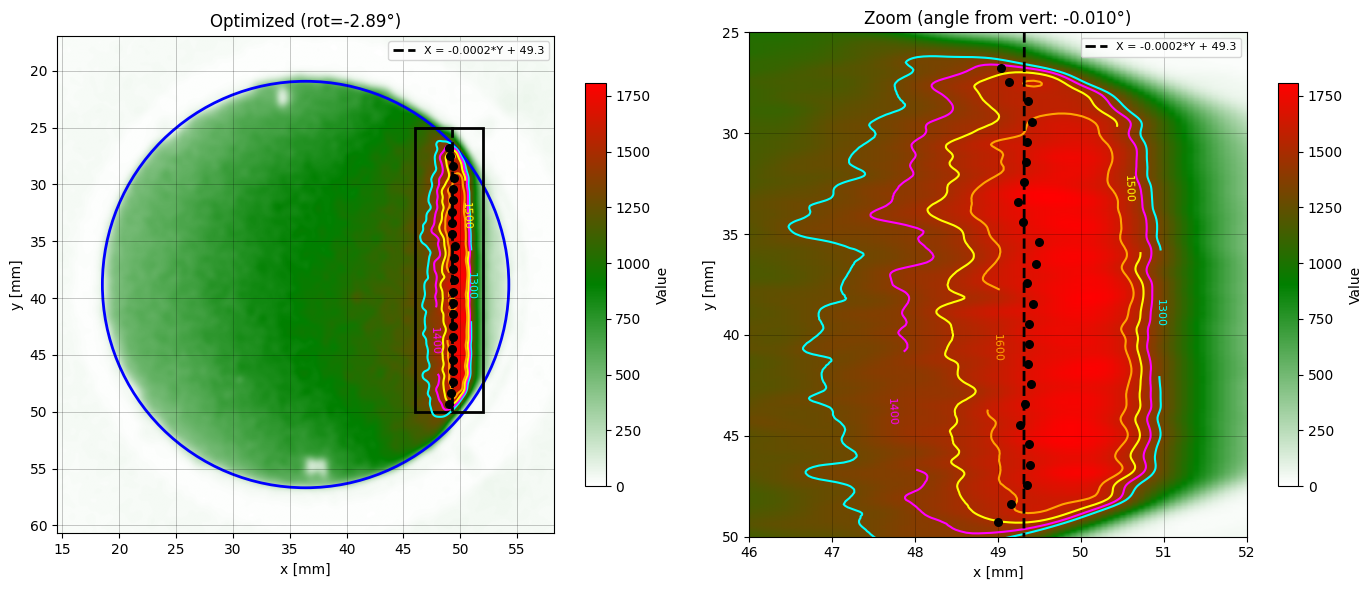

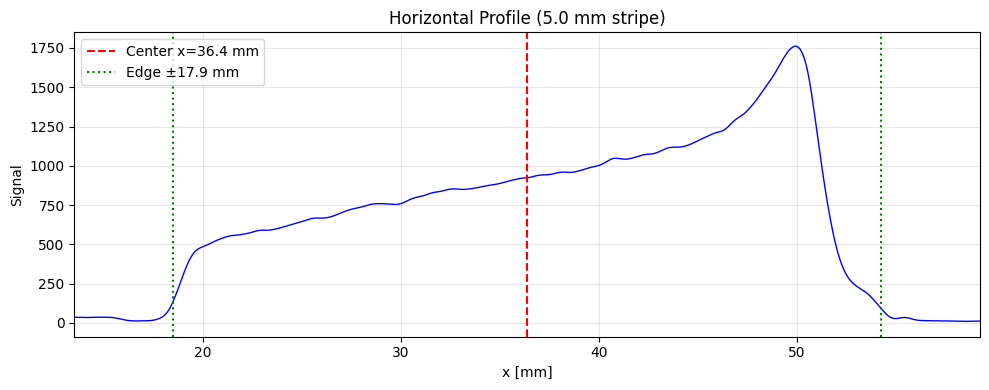


Saved to: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25\mbo_aic144_single_foil_rotated.npz


In [35]:
# Apply optimal rotation
img_optimized = rotate_around_center(image_rotated, best_angle, center_px)
img_opt_smooth = smooth_image(img_optimized)
opt_centers = calc_gravity_centers(img_opt_smooth, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
opt_angle_vert, opt_fit = calc_angle_from_vertical(opt_centers)

print(f"After rotation by {best_angle:.3f}°:")
print(f"  Line: X = {opt_fit[0]:.6f}*Y + {opt_fit[1]:.2f}")
print(f"  Angle from vertical: {opt_angle_vert:.4f}°")

# Visualize optimized result
plot_dual_view(img_opt_smooth, opt_centers, opt_fit, circle_mm, extent, xlim_crop, ylim_crop,
               ZOOM_XLIM, ZOOM_YLIM, ISO_LEVELS,
               f'Optimized (rot={best_angle:.2f}°)',
               f'Zoom (angle from vert: {opt_angle_vert:.3f}°)')

# Calculate horizontal profile through center
h_opt, w_opt = img_opt_smooth.shape
stripe_px = int(PROFILE_STRIPE_MM / PIXEL_SIZE_MM / 2)
cy_px = int(cy_mm / PIXEL_SIZE_MM)
y0, y1 = max(0, cy_px - stripe_px), min(h_opt, cy_px + stripe_px)
profile_values = img_opt_smooth[y0:y1, :].mean(axis=0)
profile_x_mm = np.arange(len(profile_values)) * PIXEL_SIZE_MM

# Plot profile
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(profile_x_mm, profile_values, 'b-', lw=1)
ax.axvline(cx_mm, c='r', ls='--', lw=1.5, label=f'Center x={cx_mm:.1f} mm')
ax.axvline(cx_mm - r_mm, c='g', ls=':', lw=1.5, label=f'Edge ±{r_mm:.1f} mm')
ax.axvline(cx_mm + r_mm, c='g', ls=':', lw=1.5)
ax.set(xlabel='x [mm]', ylabel='Signal', title=f'Horizontal Profile ({PROFILE_STRIPE_MM} mm stripe)')
ax.set_xlim(cx_mm - r_mm - 5, cx_mm + r_mm + 5)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Save results
np.savez(OUTPUT_FILE,
    image_rotated=img_optimized, image_rotated_smooth=img_opt_smooth,
    profile_x_mm=profile_x_mm, profile_values=profile_values,
    rotation_angle_deg=best_angle, pixel_size_mm=PIXEL_SIZE_MM,
    circle_center_x_mm=cx_mm, circle_center_y_mm=cy_mm, circle_radius_mm=r_mm)
print(f"\nSaved to: {OUTPUT_FILE}")